--- Mean Total Spend by Education Level ---
Graduation: $621.69 (n=1116)
PhD       : $676.73 (n=481)
Master    : $609.77 (n=365)
Basic     : $81.80 (n=54)
2n Cycle  : $494.93 (n=200)

             ONE-WAY ANOVA RESULTS: TOTAL SPEND vs. EDUCATION
F-Statistic: 14.0731
P-value: 0.0000

--- Conclusion ---
Conclusion: **Reject the Null Hypothesis** (p < 0.05).
Interpretation: There is a **statistically significant difference** in the Average Total Spend across the various Education Levels.
Actionable Insight: **A post-hoc test (like Tukey's HSD)** is required to determine *which specific pairs* of education levels spend significantly more or less.


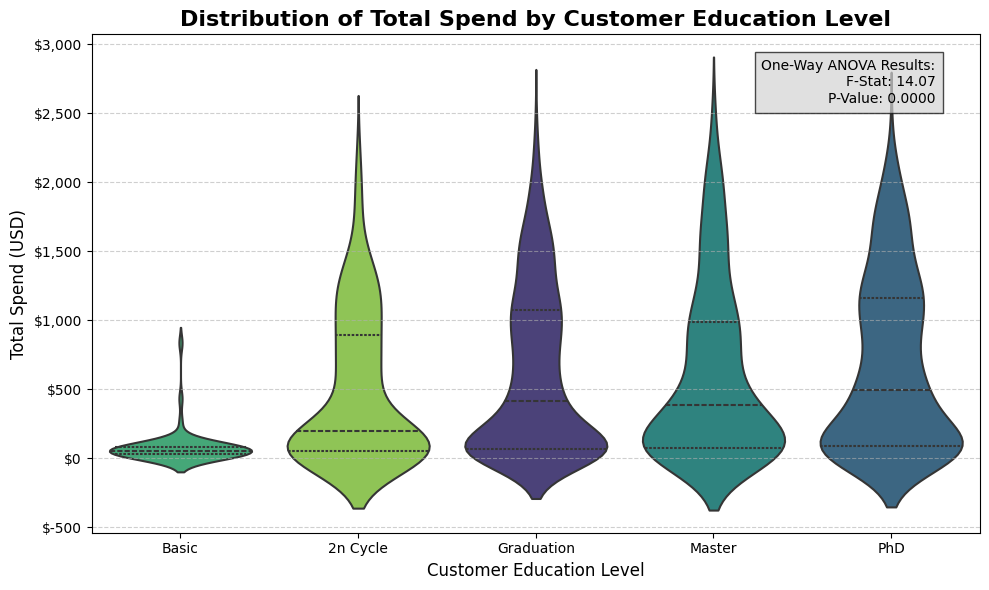

In [ ]:
import pandas as pd
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = pd.read_csv('marketing_campaign.csv')
df.columns = df.columns.str.strip().str.replace(' ', '_') 
df_clean = df.dropna(subset=['Income', 'Education']).copy()

spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_clean['TotalSpend'] = df_clean[spending_cols].sum(axis=1)

unique_education = df_clean['Education'].unique()
spend_groups = []

print("--- Mean Total Spend by Education Level ---")
for group in unique_education:
    group_data = df_clean[df_clean['Education'] == group]['TotalSpend']
    spend_groups.append(group_data)
    print(f"{group:<10}: ${group_data.mean():.2f} (n={len(group_data)})")

f_stat, p_value = stats.f_oneway(*spend_groups)

print("\n" + "="*60)
print("             ONE-WAY ANOVA RESULTS: TOTAL SPEND vs. EDUCATION")
print("="*60)
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
print("\n--- Conclusion ---")
if p_value < alpha:
    print("Conclusion: **Reject the Null Hypothesis** (p < 0.05).")
    print("Interpretation: There is a **statistically significant difference** in the Average Total Spend across the various Education Levels.")
    print("Actionable Insight: **A post-hoc test (like Tukey's HSD)** is required to determine *which specific pairs* of education levels spend significantly more or less.")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (p > 0.05).")
    print("Interpretation: The average total spend is not significantly different across education levels.")
print("="*60)

plt.figure(figsize=(10, 6))

education_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']

sns.violinplot(
    x='Education', 
    y='TotalSpend', 
    data=df_clean,
    order=education_order,
    hue='Education',
    palette='viridis', 
    inner='quartile', 
    linewidth=1.5,
    legend=False
)

formatter = ticker.FuncFormatter(lambda x, p: '${:,.0f}'.format(x))
plt.gca().yaxis.set_major_formatter(formatter)

plt.text(
    0.95, 
    0.95, 
    f"One-Way ANOVA Results:\nF-Stat: {f_stat:.2f}\nP-Value: {p_value:.4f}",
    transform=plt.gca().transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    bbox={'facecolor': 'lightgray', 'alpha': 0.7, 'pad': 5}
)

plt.title(
    "Distribution of Total Spend by Customer Education Level", 
    fontsize=16, 
    fontweight='bold'
)
plt.xlabel("Customer Education Level", fontsize=12)
plt.ylabel("Total Spend (USD)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()